In [1]:
import os
import cv2
import csv
import math
import time
import shutil
import joblib
import pandas as pd
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
# ---------- SP2 YOLO & Rule-Based ----------
video_folder = Path(r"C:\Users\Miran\Documents\Senior_Project_2\child\SP2_Childset\SP2_Child_Dataset_Video\test")
true_labels_file = Path(r"C:\Users\Miran\Documents\Senior_Project_2\child\True_Result.csv")
model_path = Path(r"C:\Users\Miran\Documents\Senior_Project_2\child\YOLO-Child.pt")
ML_model_path  = Path(r"C:\Users\Miran\Documents\Senior_Project_2\child\childLG.pkl")
ML_model = joblib.load(ML_model_path)
model = YOLO(model_path)

In [3]:
# Distance threshold used to match detections with previous tracked positions
DIST_THRESHOLD = 180

In [4]:
# ---------------- TIME & SENSITIVITY SETTINGS ----------------
ALONE_THRESHOLD = 3.0       # Time (in seconds) a child must stay alone before triggering alert
ADULT_CONFIRM_TIME = 3.0    # Time (in seconds) adult must be visible to reset alone counter
ADULT_CONF_THRESHOLD = 0.7  # Confidence threshold for adult detection (higher for reliability)
CHILD_CONF_THRESHOLD = 0.3  # Confidence threshold for child detection
 

In [5]:
TOTAL_ALONE_TIME = 0        # Total accumulated time the child has been alone across the entire video (for ML feature)
MAX_ALONE_TIME = 0          # Longest continuous duration the child stayed alone (captures worst-case scenario)
ADULT_FRAME_COUNT = 0       # Number of frames where at least one reliable adult is detected (used for ratio feature)
TOTAL_FRAMES = 0            # Total number of processed frames in the video (used for normalization)

In [6]:
# Calculate Euclidean distance between two 2D points.
def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

In [7]:
def ml_predict(child_count, adult_count, max_alone_time, total_alone_time, adult_presence_ratio):
    ML_model = joblib.load(ML_model_path)
    X = pd.DataFrame([{
        "num_children": child_count,
        "num_adults": adult_count,
        "max_alone_time": max_alone_time,
        "total_alone_time": total_alone_time,
        "adult_presence_ratio": adult_presence_ratio
    }])
    return ML_model.predict(X)[0]

In [8]:
def analyze_video(video_path, model, conf_threshold=0.3, show=True):
    cap = cv2.VideoCapture(str(video_path))
    
    names = model.names
    
    # ---------------- STATE VARIABLES ----------------
    alone_start_time = None         # Timestamp when child started being alone
    adult_appearance_start = None   # Timestamp when dult started appearing
    alert_triggered = False

    # ---------------- TRACKING DICTIONARIES ----------------
    id_last_position = {}   # Stores last known position of each unified ID
    byteID_to_unified = {}  # Maps YOLO tracker ID to our custom unified ID
    next_unified_id = 1     # Counter to generate new unified IDs

    # ---------------- ML FEATURE VARIABLES (ADD-ONLY) ----------------
    total_alone_time = 0
    max_alone_time = 0
    adult_frame_count = 0
    total_frames = 0
    
    while True:
        # Read a single frame from the video
        ret, frame = cap.read()
        # Stop if no more frames are available
        if not ret:
            break
        timestamp = time.time()  # Record current time

        # count frames
        total_frames += 1
        
        # Run YOLO tracking on current frame
        results = model.track(source=frame,
            conf=conf_threshold,
            persist=True,
            stream=False,
            verbose=False,
            tracker="bytetrack.yaml"
        )

        current_children_ids = []
        current_adults_ids = []
        max_child_conf = 0

        for r in results:
            if r.boxes is None: continue

             # Extract labels, confidence scores, bounding boxes, and tracker IDs
            labels = [model.names[int(c)] for c in r.boxes.cls]
            confs = r.boxes.conf
            boxes = r.boxes.xyxy
            ids = r.boxes.id if r.boxes.id is not None else [None]*len(labels)

            for label, box, conf_score, byte_id in zip(labels, boxes, confs, ids):
                conf_val = float(conf_score)
                
                # Bounding box coordinates
                x1, y1, x2, y2 = map(int, box)
                
                # Compute center of bounding box
                cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

                
                if byte_id is not None:
                # If this YOLO ID was never seen before
                    if byte_id not in byteID_to_unified:
                        matched_id = None
                        
                        # Try matching with previous unified IDs
                        for uid, last_pos in id_last_position.items():
                            if euclidean((cx, cy), last_pos) < DIST_THRESHOLD:
                                matched_id = uid
                                break
                        # If no match found, create new unified ID
                        if matched_id is None:
                            matched_id = next_unified_id
                            next_unified_id += 1
                        byteID_to_unified[byte_id] = matched_id

                    unified_id = byteID_to_unified[byte_id]
                    id_last_position[unified_id] = (cx, cy)
                else:
                        continue  # Ignore detection if no tracking ID

                if label == "child" and conf_val >= CHILD_CONF_THRESHOLD:
                    current_children_ids.append(unified_id)
                    max_child_conf = max(max_child_conf, conf_val)
                    #BGR
                    color = (0, 0, 255)
                elif label == "adult" and conf_score >= ADULT_CONF_THRESHOLD:
                    current_adults_ids.append(unified_id)
                    color = (255, 0, 0)
                else:
                    continue
                
                if show:
                    label_str = f"ID:{unified_id} {label} {conf_val:.2f}"
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label_str, (x1, y1 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                
        has_child = len(current_children_ids) > 0
        has_reliable_adult = len(current_adults_ids) > 0
        
                # adult presence tracking
        if has_reliable_adult:
            adult_frame_count += 1
            
        if has_child:
            if has_reliable_adult:
                # Start counting adult presence duration
                if adult_appearance_start is None:
                    adult_appearance_start = timestamp

                # If adult confirmed for enough time, reset alone counter
                if (timestamp - adult_appearance_start) >= ADULT_CONFIRM_TIME:
                    alone_start_time = None
                    # accumulate total alone time
                if alone_start_time is not None:
                    total_alone_time += (timestamp - alone_start_time)
                    
                    
            else:
                # No reliable adult detected
                adult_appearance_start = None
                if alone_start_time is None:
                    alone_start_time = timestamp

                elapsed_alone = timestamp - alone_start_time

                # track max alone duration
                max_alone_time = max(max_alone_time, elapsed_alone)
                
                # Trigger alert if child alone for too long
                if elapsed_alone >= ALONE_THRESHOLD:
                    adult_ratio = adult_frame_count / max(total_frames, 1)
                    ml_decision = ml_predict(
                        child_count=len(current_children_ids),
                        adult_count=len(current_adults_ids),
                        max_alone_time=max_alone_time,
                        total_alone_time=total_alone_time,
                        adult_presence_ratio=adult_ratio
                    )
                    if ml_decision == 1:
                        alert_triggered = True
                        if show:
                                cv2.putText(frame,
                                    f"ALERT: CHILD ALONE!({elapsed_alone:.1f}s)",
                                    (50, 50),
                                    cv2.FONT_HERSHEY_SIMPLEX,
                                    0.7,
                                    (0, 0, 255),
                                    2
                                )
                                
        else:
            alone_start_time = None
            adult_appearance_start = None
            

        if show:
            cv2.imshow("Child Monitor", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    cap.release()
    cv2.destroyAllWindows()
    print(f"Video: {os.path.basename(video_path)} | ALERT: {alert_triggered}")
    return {"video": os.path.basename(video_path), "alert": alert_triggered}

In [9]:
def process_videos(video_folder, model, conf):
    videos = [f for f in os.listdir(video_folder)
              if f.lower().endswith((".mp4"))]
    results_list = []

    for file_name in videos:
        video_path = video_folder / file_name
        result = analyze_video(video_path, model, conf_threshold=conf, show=True)
        results_list.append(result)
        
    return results_list

In [10]:
results_list = process_videos(video_folder, model,0.3)

Video: adult-3.mp4 | ALERT: False
Video: child-29.mp4 | ALERT: True
Video: child-30.mp4 | ALERT: True
Video: child-31.mp4 | ALERT: True
Video: child-36.mp4 | ALERT: True
Video: child-37.mp4 | ALERT: True
Video: child-42.mp4 | ALERT: True
Video: family-10.mp4 | ALERT: False
Video: family-14.mp4 | ALERT: False
Video: family-19.mp4 | ALERT: False
Video: family-2.mp4 | ALERT: False
Video: family-27.mp4 | ALERT: False


In [11]:
true_df = pd.read_csv(true_labels_file)
true_dict = dict(zip(true_df['video_name'], true_df['Alert']))

y_true = []
y_pred = []

for r in results_list:
    video_name = r["video"]
    y_pred.append(int(r["alert"]))
    y_true.append(true_dict.get(video_name, 0))


acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)

print("\n--- Metrics ---")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")



--- Metrics ---
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%


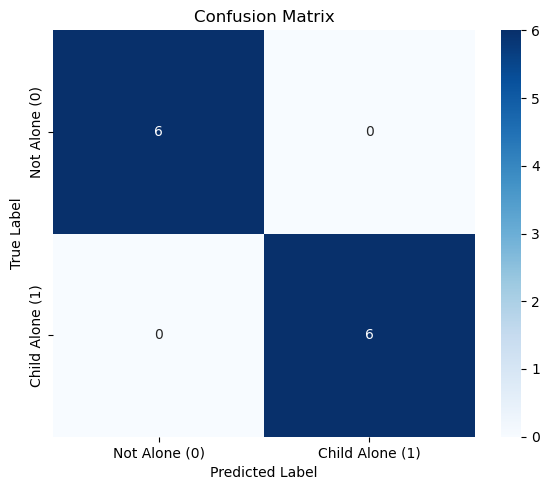

In [12]:
cm = confusion_matrix(y_true, y_pred)  # [[TN, FP],[FN, TP]]
labels = ["Not Alone (0)", "Child Alone (1)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()